# Day 10: Decision Tree Classification
# 30 Days Machine Learning Challenge

print("Decision Tree Classification")

In [72]:
#Import libraries
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

In [73]:
#load dataset
df = pd.read_csv("/content/StudentPerformanceFactors.csv")

df.head()
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nDataset Information:")
df.info()

Shape: (6607, 20)

Columns:
Index(['Hours_Studied', 'Attendance', 'Parental_Involvement',
       'Access_to_Resources', 'Extracurricular_Activities', 'Sleep_Hours',
       'Previous_Scores', 'Motivation_Level', 'Internet_Access',
       'Tutoring_Sessions', 'Family_Income', 'Teacher_Quality', 'School_Type',
       'Peer_Influence', 'Physical_Activity', 'Learning_Disabilities',
       'Parental_Education_Level', 'Distance_from_Home', 'Gender',
       'Exam_Score'],
      dtype='object')

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6607 non-null   int64 
 1   Attendance                  6607 non-null   int64 
 2   Parental_Involvement        6607 non-null   object
 3   Access_to_Resources         6607 non-null   object
 4   Extracurricular_Activities  6607 non-nu

In [74]:
#Check Missing Values
df.isnull().sum()

#Also check duplicates:

print("Duplicate rows:", df.duplicated().sum())
#Remove duplicates:

df = df.drop_duplicates()

Duplicate rows: 0


In [87]:
#Explore Target

median_score = df["Exam_Score"].median()

df["Pass"] = (df["Exam_Score"] >= median_score).astype(int)

print("Median Exam Score:", median_score)
print(df["Pass"].value_counts())

Median Exam Score: 67.0
Pass
1    3725
0    2882
Name: count, dtype: int64


In [88]:
#Select Features
X = df[
    [
        "Hours_Studied",
        "Attendance",
        "Previous_Scores",
        "Sleep_Hours",
        "Tutoring_Sessions",
        "Physical_Activity"
    ]
]

df["Pass"] = (df["Exam_Score"] >= 40).astype(int)
#Check them:

print("Features:")
print(X.head())

print("\nTarget:")
print(y.head())
print("Target Distribution:")
print(y.value_counts())

Features:
   Hours_Studied  Attendance  Previous_Scores  Sleep_Hours  Tutoring_Sessions  \
0             23          84               73            7                  0   
1             19          64               59            8                  2   
2             24          98               91            7                  2   
3             29          89               98            8                  1   
4             19          92               65            6                  3   

   Physical_Activity  
0                  3  
1                  4  
2                  4  
3                  4  
4                  4  

Target:
0    1
1    1
2    1
3    1
4    1
Name: Pass, dtype: int64
Target Distribution:
Pass
1    6607
Name: count, dtype: int64


In [77]:
#Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (5285, 6)
Testing data: (1322, 6)


In [78]:
#Create Decision Tree
model = DecisionTreeClassifier(
    criterion="gini",
    max_depth=5,
    random_state=42
)

model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [89]:
#Prediction
y_pred = model.predict(X_test)

print("Predicted:", y_pred[:20])
print("Actual:   ", y_test.values[:20])

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Accuracy:", f"{accuracy * 100:.2f}%")

#Confusion Matrix
cm = confusion_matrix(
    y_test,
    y_pred,
    labels=[0, 1]
)

print(cm)

Predicted: [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
Actual:    [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
Accuracy: 1.0
Accuracy: 100.00%
[[   0    0]
 [   0 1322]]


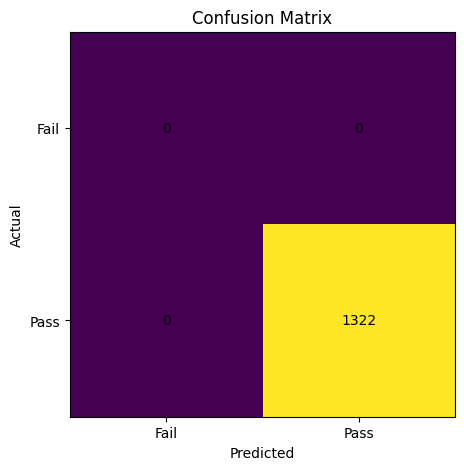

In [80]:
plt.figure(figsize=(6, 5))

plt.imshow(cm)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.xticks([0, 1], ["Fail", "Pass"])
plt.yticks([0, 1], ["Fail", "Pass"])

for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.show()

In [81]:
#Classification Report
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred,
        labels=[0, 1],
        target_names=["Fail", "Pass"],
        zero_division=0
    )
)

              precision    recall  f1-score   support

        Fail       0.00      0.00      0.00         0
        Pass       1.00      1.00      1.00      1322

    accuracy                           1.00      1322
   macro avg       0.50      0.50      0.50      1322
weighted avg       1.00      1.00      1.00      1322



In [90]:
#Feature Importance
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance)

             Feature  Importance
0      Hours_Studied         0.0
1         Attendance         0.0
2    Previous_Scores         0.0
3        Sleep_Hours         0.0
4  Tutoring_Sessions         0.0
5  Physical_Activity         0.0


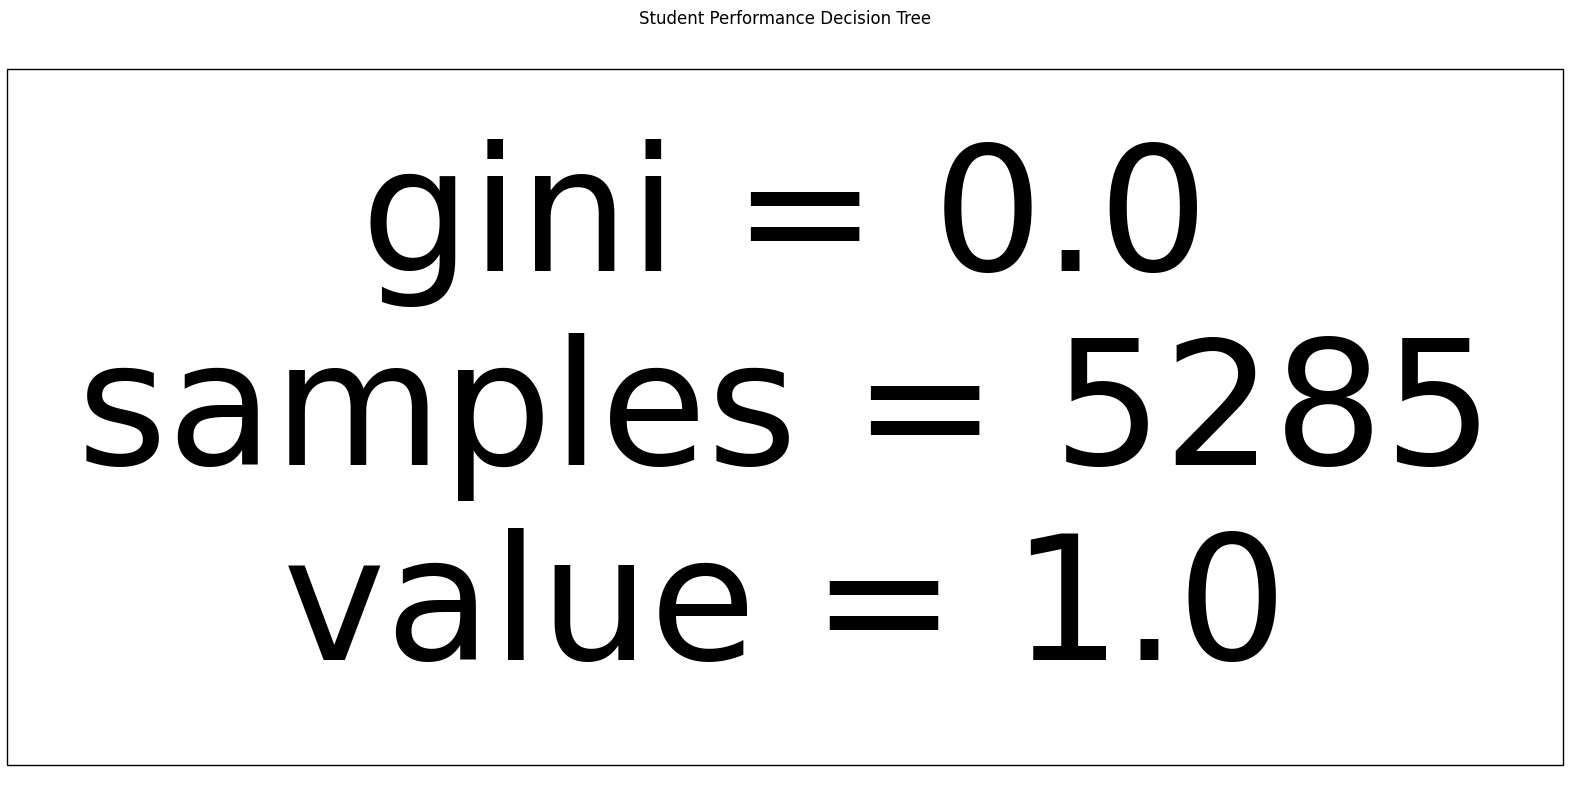

In [91]:
#Visualize Decision Tree
plt.figure(figsize=(20, 10))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=["Fail", "Pass"],
    filled=True
)

plt.title("Student Performance Decision Tree")

plt.show()

In [92]:
print("Pass/Fail distribution:")
print(df["Pass"].value_counts())

print("\nUnique target values:")
print(df["Pass"].unique())

Pass/Fail distribution:
Pass
1    6607
Name: count, dtype: int64

Unique target values:
[1]


             Feature  Importance
0      Hours_Studied         0.0
1         Attendance         0.0
2    Previous_Scores         0.0
3        Sleep_Hours         0.0
4  Tutoring_Sessions         0.0
5  Physical_Activity         0.0


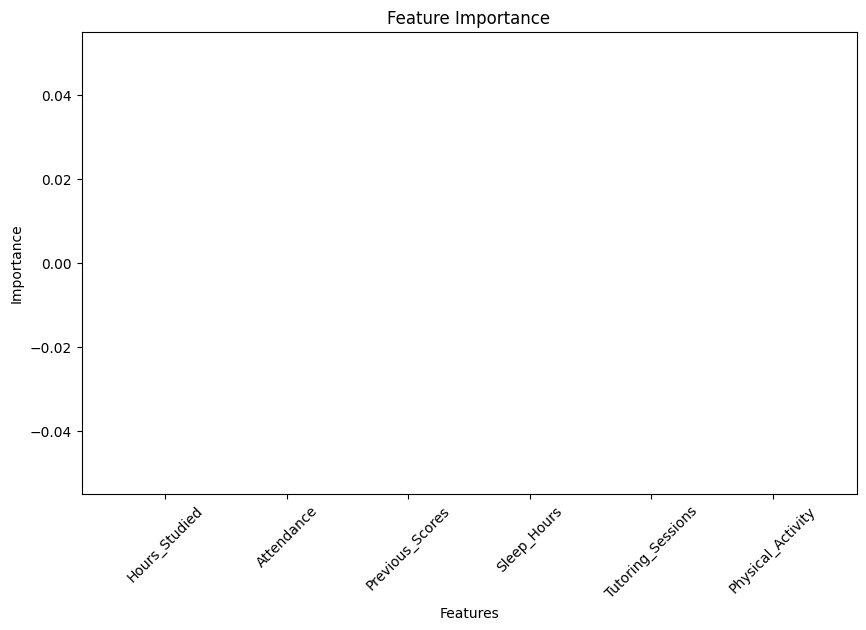

In [93]:
#Feature Importance
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance)



In [85]:
#Predict a New Student
new_student = pd.DataFrame({
    "Hours_Studied": [6],
    "Attendance": [85],
    "Previous_Scores": [70],
    "Sleep_Hours": [7],
    "Tutoring_Sessions": [2],
    "Physical_Activity": [3]
})

prediction = model.predict(new_student)

if prediction[0] == 1:
    print("Prediction: Student is likely to PASS")
else:
    print("Prediction: Student is likely to FAIL")

Prediction: Student is likely to PASS


In [86]:
#Check Overfitting

#Try different tree depths:

depths = [2, 3, 4, 5, 6, 8, 10]

results = []

for depth in depths:

    tree = DecisionTreeClassifier(
        criterion="gini",
        max_depth=depth,
        random_state=42
    )

    tree.fit(X_train, y_train)

    train_accuracy = tree.score(X_train, y_train)
    test_accuracy = tree.score(X_test, y_test)

    results.append({
        "Max Depth": depth,
        "Training Accuracy": train_accuracy,
        "Testing Accuracy": test_accuracy
    })

results_df = pd.DataFrame(results)

results_df

,Max Depth,Training Accuracy,Testing Accuracy
0,2,1.0,1.0
1,3,1.0,1.0
2,4,1.0,1.0
3,5,1.0,1.0
4,6,1.0,1.0
5,8,1.0,1.0
6,10,1.0,1.0
